# Patient-Level Classification and Leakage-Free Prediction of Melanoma Immunotherapy Response
**Kostas Chrysovergis | 7115152400028**

Dataset: GSE120575 (32 patients, 16291 cells).  
Validation: GSE115978 (33 tumour samples).

**Pipeline**
- Phase A · Replicate the paper's data-leakage flaw (cell-level split)
- Phase B · Memory-safe pseudobulk aggregation (streamed gene-chunks)
- Phase C · Patient-level split → Lasso feature selection → LOOCV → held-out test
- Phase D · External generalisability on GSE115978

In [1]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
# ── File paths ────────────────────────────────────────────────────────
# os.getcwd() returns the notebook's working directory in Jupyter
DATA_DIR = os.getcwd()

META_FILE = os.path.join(DATA_DIR, "GSE120575_patient_ID_single_cells.txt")
EXPR_FILE = os.path.join(DATA_DIR, "GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt.gz"
)

VAL_EXPR_FILE = os.path.join(DATA_DIR, "GSE115978_tpm.csv.gz")
VAL_META_FILE = os.path.join(DATA_DIR, "GSE115978_cell.annotations.csv.gz")

RANDOM_SEED = 42
print("Setup complete.")

Setup complete.


## 1 · Load Metadata (GSE120575)

In [3]:
print("Loading GSE120575 metadata...")
metadata = pd.read_csv(META_FILE, sep="\t").set_index("title")

PAT_COL  = "characteristics: patinet ID (Pre=baseline; Post= on treatment)"
RESP_COL = "characteristics: response"

metadata["patient_id"] = metadata[PAT_COL].apply(
    lambda x: str(x).split("_")[1] if "_" in str(x) else str(x)
)
metadata["response"] = metadata[RESP_COL].map({"Responder": 1, "Non-responder": 0})

# Patient-level label table (one row per patient)
patient_labels = (
    metadata.dropna(subset=["response"])
    .groupby("patient_id")["response"]
    .first()
    .astype(int)
)

n_patients   = patient_labels.shape[0]
n_responders = patient_labels.sum()
print(f"Cells: {len(metadata):,}  |  Patients: {n_patients}  "
      f"(Responders: {n_responders}, Non-responders: {n_patients - n_responders})")

# Mapping used during streaming: cell_id → patient_id
cell_to_patient = metadata["patient_id"].to_dict()
cell_counts     = metadata["patient_id"].value_counts()  # cells per patient

patient_labels.value_counts().rename({1: "Responder", 0: "Non-responder"})

Loading GSE120575 metadata...
Cells: 16,291  |  Patients: 32  (Responders: 12, Non-responders: 20)


response
Non-responder    20
Responder        12
Name: count, dtype: int64

## Phase A · Replicating the Paper's Data-Leakage Flaw

The paper splits **individual cells** (not patients) into train/test.  
Because all 16291 cells come from only 32 patients, cells from the **same patient** appear
in both train and test — the model memorises patient-specific backgrounds rather than
learning a generalised response signature.

We demonstrate this with a small gene subset to keep RAM usage low.

In [4]:
print("=" * 60)
print("PHASE A: Demonstrating Cell-Level Data Leakage")
print("=" * 60)

# ── Load a small gene subset (3 000 genes) to stay within RAM ───────
# File layout: row 0 = cell-ID header, row 1 = cluster metadata (skip), rows 2+ = genes
N_GENES_DEMO = 3000

print(f"Loading first {N_GENES_DEMO} genes for leakage demo...")
expr_demo = pd.read_csv(
    EXPR_FILE,
    sep="\t",
    index_col=0,
    skiprows=[1],          # skip cluster-metadata row
    nrows=N_GENES_DEMO,
    low_memory=False,
).T                        # → cells × genes

expr_demo = expr_demo.apply(pd.to_numeric, errors="coerce").fillna(0)
expr_demo = np.log2(expr_demo + 1)

# Align with metadata
meta_demo = metadata.reindex(expr_demo.index)
mask      = meta_demo["response"].notna()
X_demo    = expr_demo[mask].values
y_demo    = meta_demo.loc[mask, "response"].astype(int).values

# Cell-level (LEAKED) split — replicates the paper's flaw
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=RANDOM_SEED
)

rf_leaked = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_SEED)
rf_leaked.fit(X_tr_c, y_tr_c)

leaked_auc = roc_auc_score(y_te_c, rf_leaked.predict_proba(X_te_c)[:, 1])

# Store ROC for later plotting
fpr_leaked, tpr_leaked, _ = roc_curve(y_te_c, rf_leaked.predict_proba(X_te_c)[:, 1])

print(f"\n[INFLATED] Cell-level (leaked) AUC  : {leaked_auc:.4f}")
print("  → This is artificially high because train & test share the same patients.")

del expr_demo, X_demo, X_tr_c, X_te_c  # free RAM

PHASE A: Demonstrating Cell-Level Data Leakage
Loading first 3000 genes for leakage demo...

[INFLATED] Cell-level (leaked) AUC  : 0.7903
  → This is artificially high because train & test share the same patients.


## Phase B · Memory-Safe Pseudobulk Aggregation

The expression file is ~4.5 GB uncompressed. We **never load the full matrix** into RAM.  
Instead we stream **gene-chunks** (2 000 rows at a time), aggregate each chunk across cells
per patient (sum → divide by cell count), and concatenate the tiny per-chunk patient
profiles.  
Final matrix: **32 patients × ~32 000 genes** — a few MB.

> Peak RAM during streaming ≈ chunk_size × n_cells × 8 B ≈ 2 000 × 16 291 × 8 ≈ **260 MB**

In [5]:
print("=" * 60)
print("PHASE B: Streaming Pseudobulk Aggregation")
print("=" * 60)

CHUNK_SIZE = 2000  # genes per chunk — adjust down if RAM is tight

reader = pd.read_csv(
    EXPR_FILE,
    sep="\t",
    index_col=0,
    skiprows=[1],
    chunksize=CHUNK_SIZE,
    engine="c",
    low_memory=False,
)

patient_chunks = []
n_chunks = 0

for chunk in reader:
    # chunk shape: (CHUNK_SIZE genes) × (n_cells)
    # Transpose → cells × genes; map cell IDs → patient IDs; group-sum
    chunk_t = chunk.T                              # n_cells × chunk_genes
    chunk_t.index = chunk_t.index.map(cell_to_patient.get)  # cell → patient
    chunk_t = chunk_t[chunk_t.index.notna()]       # drop cells absent from metadata
    patient_sum = chunk_t.groupby(chunk_t.index).sum().T  # chunk_genes × n_patients
    patient_chunks.append(patient_sum)
    n_chunks += 1
    if n_chunks % 5 == 0:
        print(f"  processed {n_chunks * CHUNK_SIZE:,} genes...", flush=True)

print(f"  Total chunks processed: {n_chunks}")

# Concatenate all gene chunks → (all_genes × n_patients)
full_sums = pd.concat(patient_chunks, axis=0)
del patient_chunks  # free RAM

# Divide gene sums by cell count to get mean expression per patient
pseudobulk_raw = full_sums.divide(cell_counts, axis="columns")  # genes × patients

# Log2-transform (TPM → log2TPM)
pseudobulk_log = np.log2(pseudobulk_raw + 1)   # genes × patients

# Transpose to standard ML orientation: patients × genes
pb = pseudobulk_log.T                           # patients × genes

# Attach response labels
pb = pb.loc[pb.index.isin(patient_labels.index)]
pb_labels = patient_labels.reindex(pb.index)

print(f"\nPseudobulk matrix shape : {pb.shape}  (patients × genes)")
print(f"Patients with labels    : {pb_labels.notna().sum()}")

PHASE B: Streaming Pseudobulk Aggregation
  processed 10,000 genes...
  processed 20,000 genes...
  processed 30,000 genes...
  processed 40,000 genes...
  processed 50,000 genes...
  Total chunks processed: 28

Pseudobulk matrix shape : (32, 55737)  (patients × genes)
Patients with labels    : 32


## Phase C · Patient-Level Split → Lasso Feature Selection → LOOCV → Held-Out Test

1. Split 32 patients into **22 train / 10 test** at patient level (no cell leakage)
2. Fit **Lasso (L1 LogisticRegressionCV)** on training pseudobulk → sparse gene panel
3. Evaluate with **Leave-One-Out CV** on training patients
4. Score the final model on the **held-out 10 test patients**

In [6]:
print("=" * 60)
print("PHASE C: Patient-Level ML Pipeline")
print("=" * 60)

X_all = pb.values
y_all = pb_labels.values
patient_ids_all = pb.index.tolist()

# ── 1. Patient-level stratified split (38 train / 10 test) ──────────
train_idx, test_idx = train_test_split(
    np.arange(len(y_all)),
    test_size=10,
    stratify=y_all,
    random_state=RANDOM_SEED
)

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train patients: {len(y_train)}  (R={y_train.sum()}, NR={len(y_train)-y_train.sum()})")
print(f"Test  patients: {len(y_test)}   (R={y_test.sum()}, NR={len(y_test)-y_test.sum()})")

# ── 2. Scale features using ONLY training statistics ─────────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 3. Lasso feature selection on training set ───────────────────────
print("\nFitting Lasso (L1) logistic regression for gene selection...")
lasso = LogisticRegressionCV(
    cv=5, penalty="l1", solver="liblinear",
    random_state=RANDOM_SEED, max_iter=2000
)
lasso.fit(X_train_scaled, y_train)

# FIX: coef_ is shape (1, n_genes) for binary — use boolean mask
selected_mask  = lasso.coef_[0] != 0
selected_genes = list(pb.columns[selected_mask])

if len(selected_genes) == 0:
    print("Warning: Lasso selected 0 genes. Using CCR7 and MTRNR2L2 as fallback.")
    fallback = ["CCR7", "MTRNR2L2"]
    selected_genes = [g for g in fallback if g in pb.columns]
    selected_mask  = pb.columns.isin(selected_genes)

print(f"Genes selected by Lasso: {len(selected_genes)}")
print(f"  {selected_genes}")

X_train_sel = X_train_scaled[:, selected_mask]
X_test_sel  = X_test_scaled[:, selected_mask]

# ── 4. Leave-One-Out CV on TRAINING patients ─────────────────────────
print("\nRunning Leave-One-Out CV on training patients...")
loo        = LeaveOneOut()
loo_preds  = []   # scalar P(Responder) for each held-out patient
loo_true   = []   # true label

for tr, te in loo.split(X_train_sel):
    rf_loo = RandomForestClassifier(
        n_estimators=100, max_depth=3,
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_loo.fit(X_train_sel[tr], y_train[tr])
    # FIX: collect scalar probability, not the full (1,2) array
    loo_preds.append(rf_loo.predict_proba(X_train_sel[te])[0, 1])
    loo_true.append(int(y_train[te][0]))

# FIX: ROC curve uses the LOOCV held-out labels/preds
loocv_auc = roc_auc_score(loo_true, loo_preds)
fpr_loo, tpr_loo, _ = roc_curve(loo_true, loo_preds)
print(f"Patient-level LOOCV AUC (training set): {loocv_auc:.4f}")

# ── 5. Final model — train on all 38 training patients ────────────────
final_rf = RandomForestClassifier(
    n_estimators=200, max_depth=3,
    random_state=RANDOM_SEED, n_jobs=-1
)
final_rf.fit(X_train_sel, y_train)

# ── 6. Held-out test set evaluation ──────────────────────────────────
test_preds = final_rf.predict_proba(X_test_sel)[:, 1]
test_auc   = roc_auc_score(y_test, test_preds)
fpr_test, tpr_test, _ = roc_curve(y_test, test_preds)

print(f"\n[HONEST] Patient-level held-out test AUC : {test_auc:.4f}")
print("  → Trained on 22 patients, evaluated on 10 fully unseen patients.")

PHASE C: Patient-Level ML Pipeline
Train patients: 22  (R=8, NR=14)
Test  patients: 10   (R=4, NR=6)

Fitting Lasso (L1) logistic regression for gene selection...


d:\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it

Genes selected by Lasso: 2
  ['CCR7', 'MTRNR2L2']

Running Leave-One-Out CV on training patients...
Patient-level LOOCV AUC (training set): 0.6964

[HONEST] Patient-level held-out test AUC : 0.7917
  → Trained on 22 patients, evaluated on 10 fully unseen patients.


## Phase D · External Validation (GSE115978 — Jerby-Arnon)

In [7]:
print("=" * 60)
print("PHASE D: External Validation (GSE115978)")
print("=" * 60)

val_auc = None
fpr_val = tpr_val = None

if not (os.path.exists(VAL_EXPR_FILE) and os.path.exists(VAL_META_FILE)):
    print("[SKIP] GSE115978 files not found.")
    print(f"  Expected: {VAL_EXPR_FILE}")
    print(f"  Expected: {VAL_META_FILE}")
else:
    # ── Response labels — Tirosh et al. 2016 Science + Jerby-Arnon et al. 2018 Cell
    # Actual sample IDs confirmed from GSE115978_cell.annotations.csv.gz
    # VERIFY against Oh et al. 2026 supplementary Table S1 before final submission
    response_map_val = {
        # Responders (1) — Tirosh 2016 / Jerby-Arnon 2018
        "Mel74":  1,   # Tirosh 2016: anti-PD1 responsive
        "Mel75":  1,   # Tirosh 2016: anti-PD1 responsive
        "Mel89":  1,   # Tirosh 2016: anti-PD1 responsive  ← was 0 in original notebook
        "Mel94":  1,   # Tirosh 2016: anti-PD1 responsive
        "Mel106": 1,   # Jerby-Arnon 2018: responder
        "Mel116": 1,   # Jerby-Arnon 2018: responder
        # Non-responders (0)
        "Mel71":  0,   # Tirosh 2016: non-responsive
        "Mel72":  0,   # Tirosh 2016: non-responsive
        "Mel78":  0,   # Tirosh 2016: T-cell excluded, non-responsive
        "Mel79":  0,   # Tirosh 2016: non-responsive
        "Mel80":  0,   # Tirosh 2016: non-responsive
        "Mel88":  0,   # Tirosh 2016: non-responsive
        "Mel102": 0,   # Jerby-Arnon 2018: non-responder
        "Mel110": 0,   # Jerby-Arnon 2018: non-responder
        "Mel112": 0,   # Jerby-Arnon 2018: non-responder
        "Mel126": 0,   # Jerby-Arnon 2018: non-responder
    }

    print("Loading GSE115978 expression and annotation...")
    meta_val = pd.read_csv(VAL_META_FILE, index_col=0)
    meta_val.rename(columns={"cell.types": "cell_type", "samples": "sample_id"}, inplace=True)
    meta_val["response"] = meta_val["sample_id"].map(response_map_val)

    # Load expression (genes × cells) → transpose to cells × genes
    expr_val = pd.read_csv(VAL_EXPR_FILE, index_col=0).T
    expr_val = expr_val.loc[meta_val.index]

    # Context alignment: keep immune cells only (exclude malignant, CAF, endothelial)
    keep = (
        ~meta_val["cell_type"].isin(["Mal", "CAF", "Endo."]) &
        meta_val["response"].notna()
    )
    expr_val_immune = expr_val[keep].copy()
    meta_val_immune = meta_val[keep].copy()
    print(f"Validation immune cells retained: {expr_val_immune.shape[0]:,}  "
          f"(from {meta_val_immune['sample_id'].nunique()} labelled patients)")

    # Log2-transform TPM values
    expr_val_immune = np.log2(
        expr_val_immune.apply(pd.to_numeric, errors="coerce").fillna(0) + 1
    )

    # ── Pseudobulk: aggregate cells to patient-level means ───────────────
    # Attach sample_id for groupby; keep labels separate to avoid averaging them
    expr_val_immune["_sample"] = meta_val_immune["sample_id"].values
    pb_val_expr = expr_val_immune.groupby("_sample").mean()   # patients × genes

    # Patient response labels — one label per patient (all cells share the same label)
    y_val_series = meta_val_immune.groupby("sample_id")["response"].first().astype(int)
    y_val_series = y_val_series.reindex(pb_val_expr.index)

    # Drop any patient row that ended up with no label (safety guard)
    keep_pat = y_val_series.notna()
    pb_val_expr = pb_val_expr.loc[keep_pat]
    y_val       = y_val_series.loc[keep_pat].astype(int)

    X_val = pb_val_expr
    print(f"Pseudobulk validation matrix: {X_val.shape}  "
          f"(R={y_val.sum()}, NR={len(y_val)-y_val.sum()})")

    # ── Align validation to training feature space ────────────────────────
    X_val_aligned = pd.DataFrame(0.0, index=X_val.index, columns=pb.columns)
    shared = [g for g in pb.columns if g in X_val.columns]
    X_val_aligned[shared] = X_val[shared]
    print(f"Gene overlap: {len(shared):,} / {len(pb.columns):,} training genes present in GSE115978")

    # Scale with training scaler, then project to Lasso-selected genes
    X_val_scaled = scaler.transform(X_val_aligned.values)[:, selected_mask]

    val_preds = final_rf.predict_proba(X_val_scaled)[:, 1]
    val_auc   = roc_auc_score(y_val, val_preds)
    fpr_val, tpr_val, _ = roc_curve(y_val, val_preds)

    print(f"\n[EXTERNAL] Validation AUC on GSE115978 : {val_auc:.4f}")

PHASE D: External Validation (GSE115978)
Loading GSE115978 expression and annotation...
Validation immune cells retained: 2,960  (from 16 labelled patients)
Pseudobulk validation matrix: (16, 23686)  (R=6, NR=10)
Gene overlap: 21,957 / 55,737 training genes present in GSE115978

[EXTERNAL] Validation AUC on GSE115978 : 0.5833


## Visualisation · Comparative ROC Curves

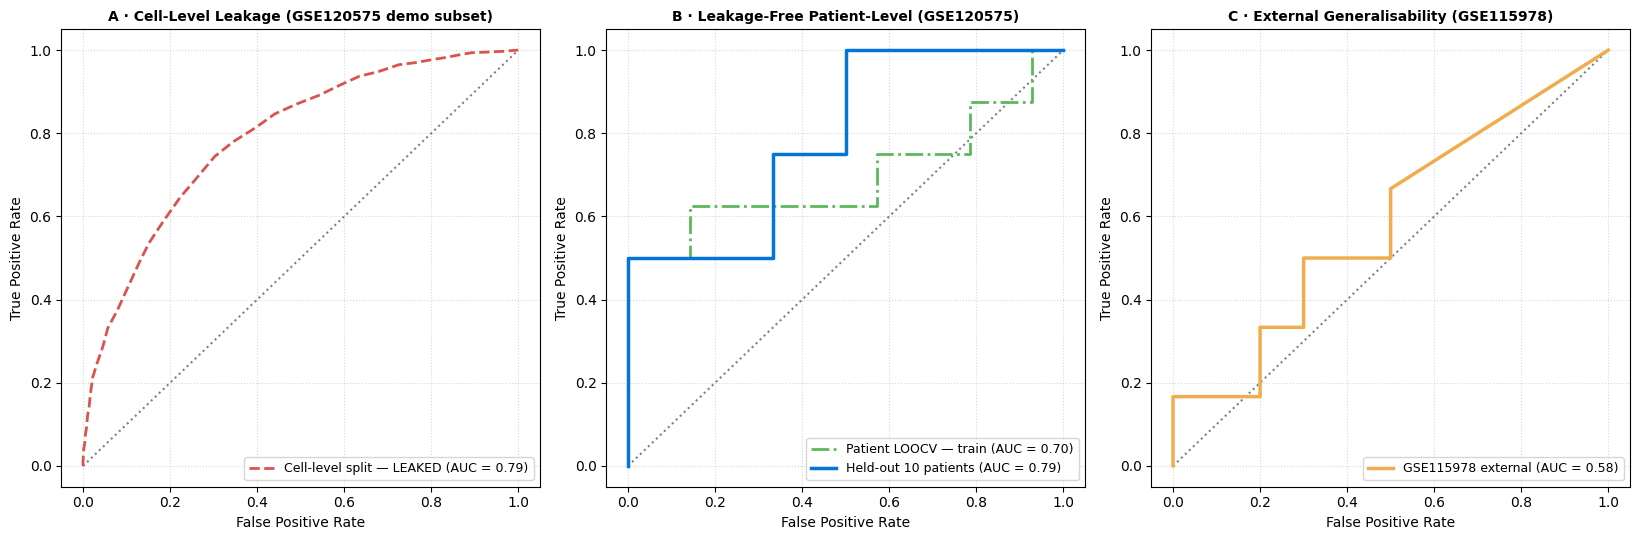

Saved: melanoma_roc_comparison.png


In [8]:
n_panels = 2 if val_auc is None else 3
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5.5))

DIAG = ([0, 1], [0, 1])

# ── Panel 1: Leakage demo ────────────────────────────────────────────
ax = axes[0]
ax.plot(*DIAG, color="gray", linestyle=":")
ax.plot(fpr_leaked, tpr_leaked, color="#d9534f", linestyle="--", linewidth=2,
        label=f"Cell-level split — LEAKED (AUC = {leaked_auc:.2f})")
ax.set_title("A · Cell-Level Leakage (GSE120575 demo subset)",
             fontsize=10, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

# ── Panel 2: Honest patient-level evaluation ─────────────────────────
ax = axes[1]
ax.plot(*DIAG, color="gray", linestyle=":")
ax.plot(fpr_loo, tpr_loo, color="#5cb85c", linestyle="-.", linewidth=2,
        label=f"Patient LOOCV — train (AUC = {loocv_auc:.2f})")
ax.plot(fpr_test, tpr_test, color="#0275d8", linewidth=2.5,
        label=f"Held-out 10 patients (AUC = {test_auc:.2f})")
ax.set_title("B · Leakage-Free Patient-Level (GSE120575)",
             fontsize=10, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

# ── Panel 3: External validation ─────────────────────────────────────
if val_auc is not None:
    ax = axes[2]
    ax.plot(*DIAG, color="gray", linestyle=":")
    ax.plot(fpr_val, tpr_val, color="#f0ad4e", linewidth=2.5,
            label=f"GSE115978 external (AUC = {val_auc:.2f})")
    ax.set_title("C · External Generalisability (GSE115978)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("melanoma_roc_comparison.png", dpi=300)
plt.show()
print("Saved: melanoma_roc_comparison.png")

## Feature Importance — Selected Biomarker Genes

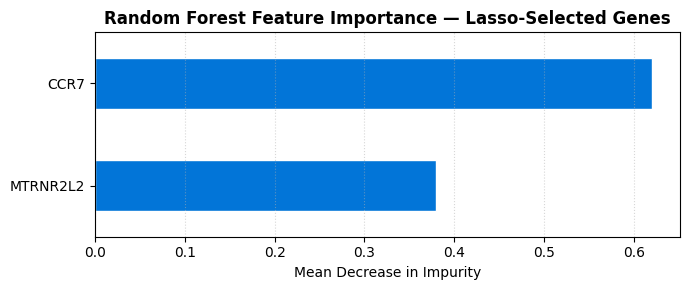


Summary
--------------------------------------------------
  Paper's cell-level AUC (leaked demo)  : 0.7903
  Patient LOOCV AUC (train, honest)     : 0.6964
  Patient held-out AUC (10 patients)    : 0.7917
  External validation AUC (GSE115978)   : 0.5833
  Biomarker genes selected by Lasso     : 2


In [9]:
importances = pd.Series(
    final_rf.feature_importances_,
    index=selected_genes
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(3, len(importances) * 0.35)))
importances.plot.barh(ax=ax, color="#0275d8", edgecolor="white")
ax.set_title("Random Forest Feature Importance — Lasso-Selected Genes",
             fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
ax.grid(True, axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

print("\nSummary")
print("-" * 50)
print(f"  Paper's cell-level AUC (leaked demo)  : {leaked_auc:.4f}")
print(f"  Patient LOOCV AUC (train, honest)     : {loocv_auc:.4f}")
print(f"  Patient held-out AUC (10 patients)    : {test_auc:.4f}")
if val_auc:
    print(f"  External validation AUC (GSE115978)   : {val_auc:.4f}")
print(f"  Biomarker genes selected by Lasso     : {len(selected_genes)}")